<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3783/1921242613.py:75: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle(f'Oshilatori Van der Pol për $\mu$ = {mu}', fontsize=12, fontweight='bold')
/tmp/ipykernel_3783/1921242613.py:102: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('Skanimi i Parametrit $\mu$', fontsize=12, fontweight='bold')
/tmp/ipykernel_3783/1921242613.py:105: Syntax

Duke gjeneruar grafikët e simulimit për mu = 0.5, 1, 3, 8...


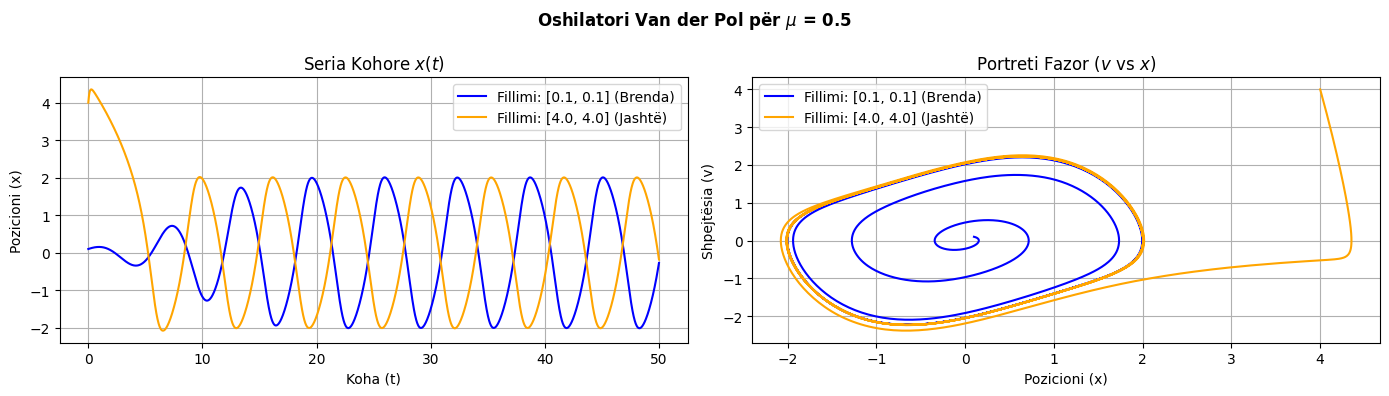

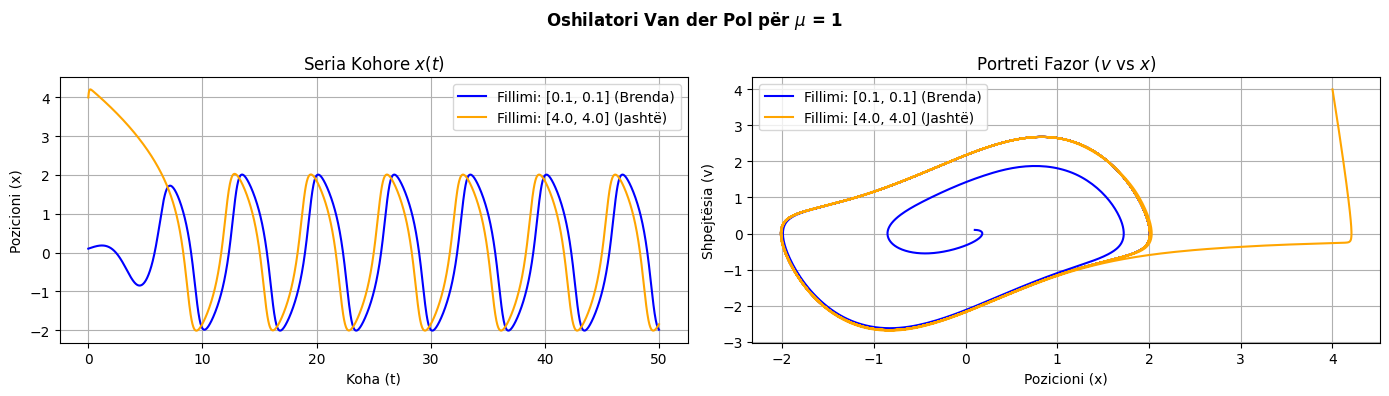

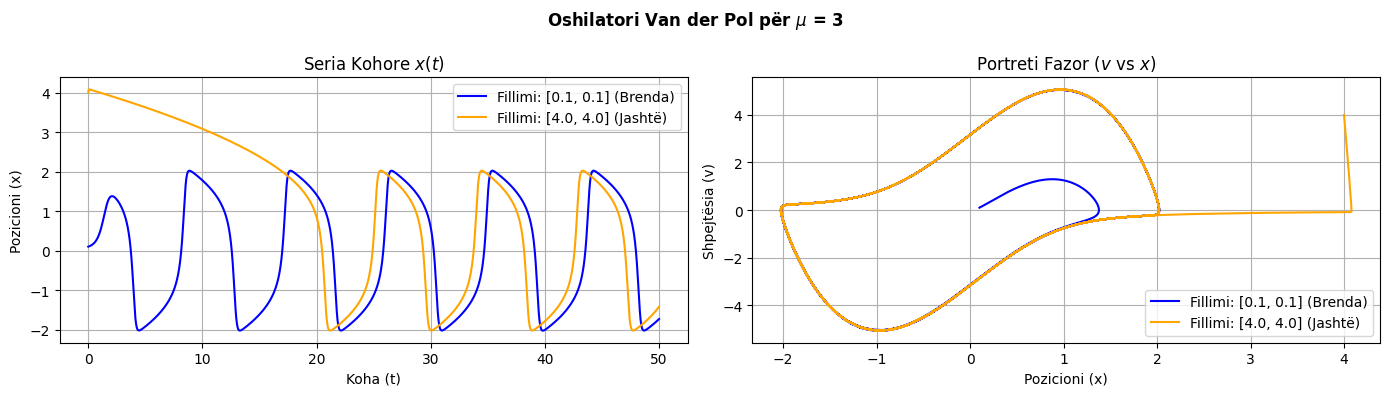

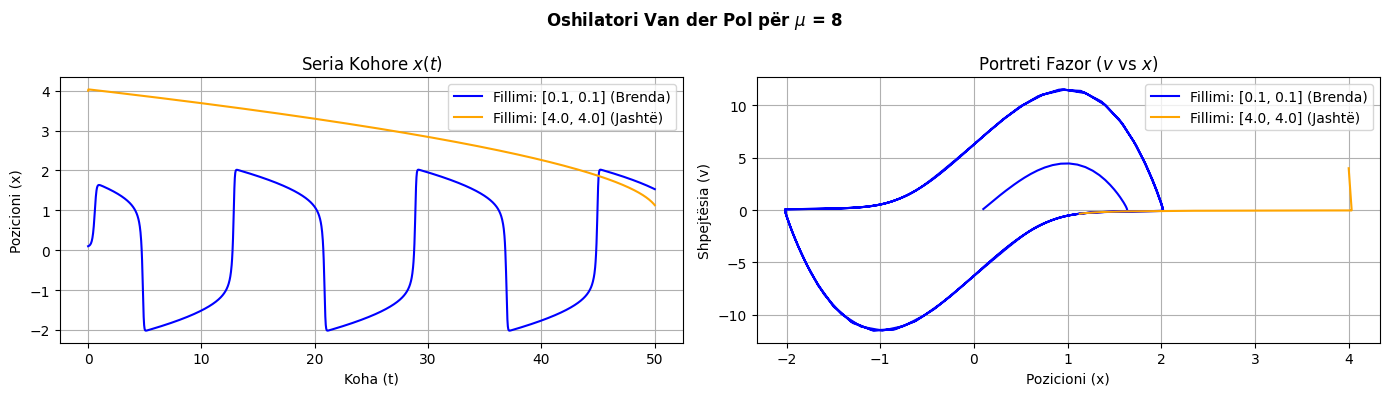


Duke gjeneruar skanimin e parametrit mu...


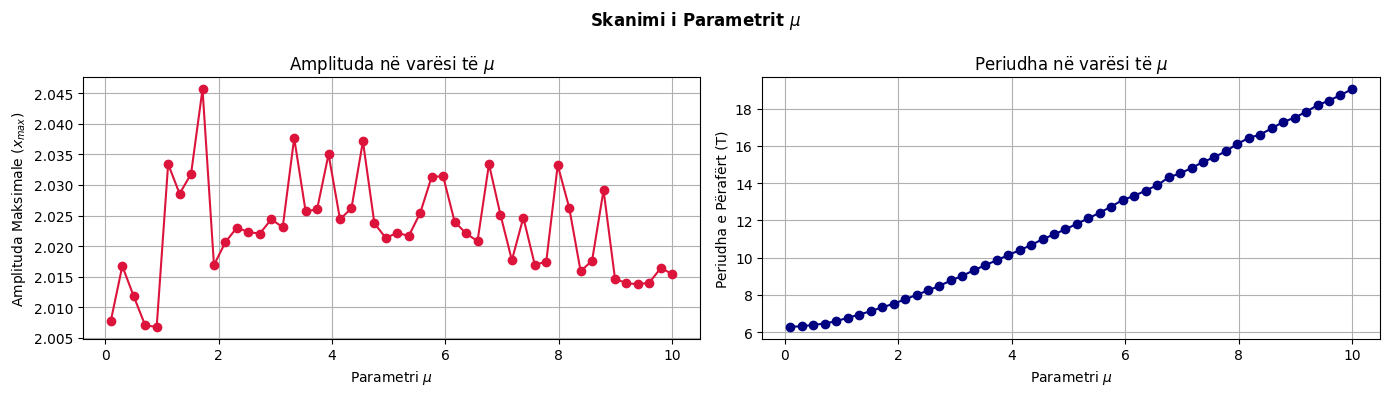

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =====================================================================
# 1. MODELI MATEMATIK (Nga src/models/vdp.py)
# =====================================================================
def van_der_pol(t, y, mu):
    """Përkufizon sistemin e ekuacioneve të Oshilatorit Van der Pol."""
    x, v = y
    dxdt = v
    dvdt = mu * (1 - x**2) * v - x
    return [dxdt, dvdt]

def integrate_vdp(mu, y0, t_span, t_eval=None):
    """Integron ekuacionin për një kusht fillestar y0 = [x0, v0]."""
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 2500)
    sol = solve_ivp(van_der_pol, t_span, y0, args=(mu,), t_eval=t_eval, method='RK45')
    return sol.t, sol.y

# =====================================================================
# 2. ESTIMIMI I PERIUDHËS (Nga src/analysis/period_estimation.py)
# =====================================================================
def estimate_period_and_amplitude(t, x, burn_in=0.5):
    """Estimon periudhën dhe amplitudën e ciklit limit."""
    start_idx = int(len(t) * burn_in)
    t_stable = t[start_idx:]
    x_stable = x[start_idx:]

    amplitude = np.max(x_stable)
    zero_crossings = []
    for i in range(1, len(x_stable)):
        if x_stable[i-1] < 0 <= x_stable[i]:
            t_zero = t_stable[i-1] - x_stable[i-1] * (t_stable[i] - t_stable[i-1]) / (x_stable[i] - x_stable[i-1])
            zero_crossings.append(t_zero)

    if len(zero_crossings) < 2:
        return None, amplitude

    periods = np.diff(zero_crossings)
    return np.mean(periods), amplitude

# =====================================================================
# 3. VIZUALIZIMI I GRAFIKËVE (Nga src/visualization/time_phase.py)
# =====================================================================
def plot_time_series(ax, t, x, label, color):
    ax.plot(t, x, label=label, color=color)
    ax.set_xlabel('Koha (t)')
    ax.set_ylabel('Pozicioni (x)')
    ax.grid(True)
    ax.legend()

def plot_phase_portrait(ax, x, v, label, color):
    ax.plot(x, v, label=label, color=color)
    ax.set_xlabel('Pozicioni (x)')
    ax.set_ylabel('Shpejtësia (v)')
    ax.grid(True)
    ax.legend()

# =====================================================================
# SIMULIMI KRYESOR (Nga scripts/run_vdp.py) - Ekzekutimi në Colab
# =====================================================================
print("Duke gjeneruar grafikët e simulimit për mu = 0.5, 1, 3, 8...")
mu_values = [0.5, 1, 3, 8]
t_span = (0, 50)

initial_conditions = [
    {'y0': [0.1, 0.1], 'label': 'Fillimi: [0.1, 0.1] (Brenda)', 'color': 'blue'},
    {'y0': [4.0, 4.0], 'label': 'Fillimi: [4.0, 4.0] (Jashtë)', 'color': 'orange'}
]

for mu in mu_values:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Oshilatori Van der Pol për $\mu$ = {mu}', fontsize=12, fontweight='bold')

    for cond in initial_conditions:
        t, y = integrate_vdp(mu, cond['y0'], t_span)
        plot_time_series(ax1, t, y[0], cond['label'], cond['color'])
        plot_phase_portrait(ax2, y[0], y[1], cond['label'], cond['color'])

    ax1.set_title('Seria Kohore $x(t)$')
    ax2.set_title('Portreti Fazor ($v$ vs $x$)')
    plt.tight_layout()
    plt.show()

# =====================================================================
# SKANIMI I PARAMETRIT (Nga scripts/scan_mu.py) - Ekzekutimi në Colab
# =====================================================================
print("\nDuke gjeneruar skanimin e parametrit mu...")
mu_range = np.linspace(0.1, 10.0, 50)
amplitudes = []
periods = []

for mu in mu_range:
    t, y = integrate_vdp(mu, [1.0, 1.0], (0, 100))
    period, amp = estimate_period_and_amplitude(t, y[0])
    periods.append(period)
    amplitudes.append(amp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Skanimi i Parametrit $\mu$', fontsize=12, fontweight='bold')

ax1.plot(mu_range, amplitudes, 'o-', color='crimson', label='Amplituda')
ax1.set_xlabel('Parametri $\mu$')
ax1.set_ylabel('Amplituda Maksimale ($x_{max}$)')
ax1.set_title('Amplituda në varësi të $\mu$')
ax1.grid(True)

ax2.plot(mu_range, periods, 'o-', color='navy', label='Periudha (T)')
ax2.set_xlabel('Parametri $\mu$')
ax2.set_ylabel('Periudha e Përafërt (T)')
ax2.set_title('Periudha në varësi të $\mu$')
ax2.grid(True)

plt.tight_layout()
plt.show()